# Reinforcement Learning for Blackjack: Initial Checkpoint

Roee Frenkel, Tony Wang, Max Xu, Patrick Faber

## 1. Introduction

### Problem Statement

The goal of this project is to train an agent to play Blackjack by framing the game as a step by step decision-making problem. Unlike supervised learning, the agent must discover a policy that maximizes long term returns through direct interaction with the environment without labeled examples or prior knowledge.

Blackjack works well because it has a small state space, episodes are short, and there exists a well-known optimal strategy (Basic Strategy) against which learned policies can be benchmarked.

## 2. Data

### The "Dataset"

Unlike supervised learning, RL does not rely on a regular dataset. Data is generated  through interaction with the environment. We use the `Gymnasium` library's `Blackjack-v1` environment (`sab=True` for Sutton & Barto rules), where the agent plays hands and receives reward signals based on outcomes.

### Features

Each observation is a tuple of three components:

| Feature | Description | Range |
|---|---|---|
| `player_sum` | Total value of the player's current hand | 4 – 21 |
| `dealer_card` | Dealer's single face-up card (Ace = 1) | 1 – 10 |
| `usable_ace` | Whether the player holds an ace counting as 11 | 0 or 1 |


### Actions

The standard `Blackjack-v1` environment offers exactly **two actions**:
- `0`: **Stand** — stop drawing cards.
- `1`: **Hit** — draw another card.

### Reward Structure

| Outcome | Reward |
|---|---|
| Player wins | +1.0 |
| Draw (push) | 0.0 |
| Player loses | -1.0 |

### Preprocessing

No preprocessing is required. The raw observation tuple is used directly as a dictionary key into each algorithm's Q-table. There are no missing values or outliers to handle.

## 3. Model Description

We implement and compare two tabular reinforcement learning algorithms, both evaluated against simple baselines. All models represent the policy through a Q-table. (lookup table mapping each (state, action) pair to an estimated value)

### Model Architecture (shared)

- **Q-Table shape:** `dict` over reachable states → `np.array([Q_stand, Q_hit])`.
- **Exploration:** Epsilon-greedy — with probability $\varepsilon$ take a random action, otherwise $\arg\max_a Q(s,a)$.
- **Epsilon:** $\varepsilon_0 = 1.0$, decaying by $\times 0.99995$ per episode, flooring at $0.05$.

---

### Algorithm 1: On-Policy First-Visit Monte Carlo Control

MC methods learn from complete episode trajectories. After each episode, the agent computes the discounted return $G$ from each visited (state, action) pair and updates Q-values using an incremental mean — no bootstrapping involved.

$$Q(s, a) \leftarrow Q(s, a) + \frac{G - Q(s, a)}{N(s, a)}$$

Blackjack is a natural fit: episodes are short, finite, and rewards are observed at the terminal state.

---

### Algorithm 2: Tabular Q-Learning (Off-Policy TD)

Q-learning updates after every step using a bootstrapped one-step return:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

Off-policy means the update always targets the greedy value at $s'$, regardless of the actual exploratory action taken. Hyperparameters: $\alpha = 0.1$, $\gamma = 1.0$.

---

### Baseline Comparisons

| Baseline | Description |
|---|---|
| **Random Policy** | Selects Hit or Stand uniformly at random |
| **Stand-on-17+ Heuristic** | Hit if player sum < 17, else Stand |

---

### Evaluation Metrics

- **Primary:** Average episodic return over a 100k-episode evaluation run (greedy policy, no exploration).
- **Secondary:** Win rate, draw rate, loss rate.
- **Training diagnostic:** Smoothed learning curve (rolling average return vs. training episode).

---
## 4. Environment Setup

In [1]:
# !pip install gymnasium matplotlib numpy seaborn

import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
#import seaborn as sns
from collections import defaultdict
from tqdm import tqdm

print(f"Gymnasium version: {gym.__version__}")

Gymnasium version: 1.2.3


In [2]:
env = gym.make('Blackjack-v1', sab=True)  # sab=True uses Sutton & Barto rules

print(f"Observation space: {env.observation_space}")
print(f"Action space:      {env.action_space}")
print(f"Actions: 0=Stand, 1=Hit")

Observation space: Tuple(Discrete(32), Discrete(11), Discrete(2))
Action space:      Discrete(2)
Actions: 0=Stand, 1=Hit


In [3]:
# Sample episodes to understand the environment
print("=== Sample Episodes ===")
for episode in range(3):
    state, _ = env.reset()
    print(f"\nEpisode {episode + 1}: start state = {state}")
    done = False
    step = 0
    while not done:
        action = env.action_space.sample()
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        step += 1
        print(f"  Step {step}: {'Hit' if action else 'Stand':5s}  ->  state={next_state}  reward={reward}")
        state = next_state
    result = 'Win' if reward > 0 else ('Draw' if reward == 0 else 'Lose')
    print(f"  Result: {result}")

=== Sample Episodes ===

Episode 1: start state = (10, 5, 0)
  Step 1: Hit    ->  state=(20, 5, 0)  reward=0.0
  Step 2: Hit    ->  state=(30, 5, 0)  reward=-1.0
  Result: Lose

Episode 2: start state = (21, 4, 1)
  Step 1: Stand  ->  state=(21, 4, 1)  reward=1.0
  Result: Win

Episode 3: start state = (14, 8, 0)
  Step 1: Stand  ->  state=(14, 8, 0)  reward=1.0
  Result: Win


---
## 5. Baseline Policies

We establish two baselines before training any RL agent. These give reference points for assessing whether learning is actually working.

`evaluate_policy` reports the average episodic return (primary metric) and win/draw/loss rates.

In [4]:
def evaluate_policy(env, policy_fn, n_episodes=100_000):
    """
    Evaluate a greedy policy over many episodes (no exploration).
    Returns a dict: avg_return, win_rate, draw_rate, lose_rate.
    """
    wins, draws, losses = 0, 0, 0
    total_return = 0.0
    for _ in range(n_episodes):
        state, _ = env.reset()
        done = False
        ep_return = 0.0
        while not done:
            action = policy_fn(state)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            ep_return += reward
        total_return += ep_return
        if reward > 0:   wins += 1
        elif reward == 0: draws += 1
        else:            losses += 1
    return dict(
        avg_return = total_return / n_episodes,
        win_rate   = wins   / n_episodes,
        draw_rate  = draws  / n_episodes,
        lose_rate  = losses / n_episodes,
    )


def print_results(label, results):
    print(f"{label:<30}  avg_return={results['avg_return']:+.4f}  "
          f"win={results['win_rate']:.2%}  draw={results['draw_rate']:.2%}  lose={results['lose_rate']:.2%}")

In [5]:
random_policy    = lambda state: env.action_space.sample()
threshold_policy = lambda state: 1 if state[0] < 17 else 0

baseline_random    = evaluate_policy(env, random_policy)
baseline_threshold = evaluate_policy(env, threshold_policy)

print_results("Random Policy",          baseline_random)
print_results("Stand-on-17+ Heuristic", baseline_threshold)

Random Policy                   avg_return=-0.3880  win=28.56%  draw=4.09%  lose=67.35%
Stand-on-17+ Heuristic          avg_return=-0.0727  win=41.33%  draw=10.06%  lose=48.60%


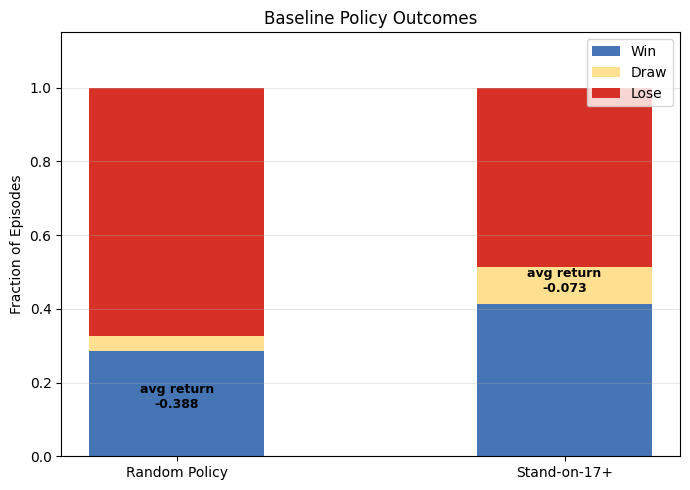

In [6]:
# Stacked bar chart: Win / Draw / Lose breakdown for baselines
labels  = ["Random Policy", "Stand-on-17+"]
results = [baseline_random, baseline_threshold]

wins   = [r['win_rate']  for r in results]
draws  = [r['draw_rate'] for r in results]
loses  = [r['lose_rate'] for r in results]

x = np.arange(len(labels))
bar_w = 0.45

fig, ax = plt.subplots(figsize=(7, 5))
bars_w = ax.bar(x, wins,  bar_w, label='Win',  color='#4575b4')
bars_d = ax.bar(x, draws, bar_w, label='Draw', color='#fee090', bottom=wins)
bars_l = ax.bar(x, loses, bar_w, label='Lose', color='#d73027',
                bottom=[w + d for w, d in zip(wins, draws)])

for bar, r in zip(bars_w, results):
    ax.text(bar.get_x() + bar.get_width() / 2,
            r['avg_return'] + 0.51, f"avg return\n{r['avg_return']:+.3f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Fraction of Episodes')
ax.set_title('Baseline Policy Outcomes')
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Monte Carlo Control

### What is Monte Carlo RL?

Monte Carlo methods estimate value functions by averaging returns from complete episodes. The agent plays a full hand, observes the final reward, then looks back at every (state, action) pair it visited and updates Q-values based on the actual total return received.

### Algorithm: First-Visit MC Control

1. **Generate episode** using epsilon-greedy policy.
2. **Compute returns** backward: $G_t = r_t + \gamma r_{t+1} + \gamma^2 r_{t+2} + \cdots$
3. **Update Q-values** for each *(state, action)* visited for the first time in the episode:
   $$Q(s, a) \leftarrow Q(s, a) + \frac{G - Q(s, a)}{N(s, a)}$$
4. **Decay epsilon** to shift from exploration toward exploitation.

In [7]:
def train_monte_carlo(
    env,
    n_episodes=500_000,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99995,
    seed=42,
):
    rng = np.random.default_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float64))
    returns_count = defaultdict(lambda: np.zeros(env.action_space.n))
    epsilon = float(epsilon_start)
    ep_returns = []

    for _ in tqdm(range(n_episodes), desc="MC Training", leave=False):
        state, _ = env.reset()
        episode = []
        done = False

        # Generate episode
        while not done:
            action = env.action_space.sample() if rng.random() < epsilon else int(np.argmax(Q[state]))
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            episode.append((state, action, reward))
            state = next_state

        ep_returns.append(sum(r for _, _, r in episode))

        # First-visit MC update (backward)
        G = 0.0
        visited = set()
        for s, a, r in reversed(episode):
            G = gamma * G + r
            if (s, a) not in visited:
                visited.add((s, a))
                returns_count[s][a] += 1
                Q[s][a] += (G - Q[s][a]) / returns_count[s][a]

        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, ep_returns

In [8]:
mc_Q, mc_returns = train_monte_carlo(env, n_episodes=500_000)
mc_policy = lambda state: int(np.argmax(mc_Q[state]))

mc_results = evaluate_policy(env, mc_policy)
print_results("Monte Carlo Control", mc_results)

Monte Carlo Control             avg_return=-0.0482  win=43.23%  draw=8.73%  lose=48.04%


---
## 7. Tabular Q-Learning (Off-Policy TD)

Q-learning updates the Q-table after every step using a bootstrapped one-step return:

$$Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right]$$

The $\max_{a'}$ makes it off-policy. Updates always target the greedy value at $s'$, regardless of the agent's exploratory behavior. This can lead to faster convergence than MC since the agent learns from every transition rather than only at episode end.

In [9]:
def train_q_learning(
    env,
    n_episodes=500_000,
    alpha=0.1,
    gamma=1.0,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.99995,
    seed=42,
):
    rng = np.random.default_rng(seed)
    Q = defaultdict(lambda: np.zeros(env.action_space.n, dtype=np.float32))
    epsilon = float(epsilon_start)
    ep_returns = []

    for _ in tqdm(range(n_episodes), desc="Q-Learning Training", leave=False):
        s, _ = env.reset()
        done = False
        ep_return = 0.0

        while not done:
            # Epsilon-greedy action selection
            a = env.action_space.sample() if rng.random() < epsilon else int(np.argmax(Q[s]))

            s2, r, terminated, truncated, _ = env.step(a)
            done = terminated or truncated
            ep_return += r

            # Q-learning update
            best_next = 0.0 if done else float(np.max(Q[s2]))
            Q[s][a] += alpha * (r + gamma * best_next - float(Q[s][a]))
            s = s2

        ep_returns.append(ep_return)
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    return Q, ep_returns

In [10]:
ql_Q, ql_returns = train_q_learning(env, n_episodes=500_000)
ql_policy = lambda state: int(np.argmax(ql_Q[state]))

ql_results = evaluate_policy(env, ql_policy)
print_results("Q-Learning", ql_results)

Q-Learning                      avg_return=-0.0604  win=42.71%  draw=8.54%  lose=48.75%


---
## 8. Initial Comparison

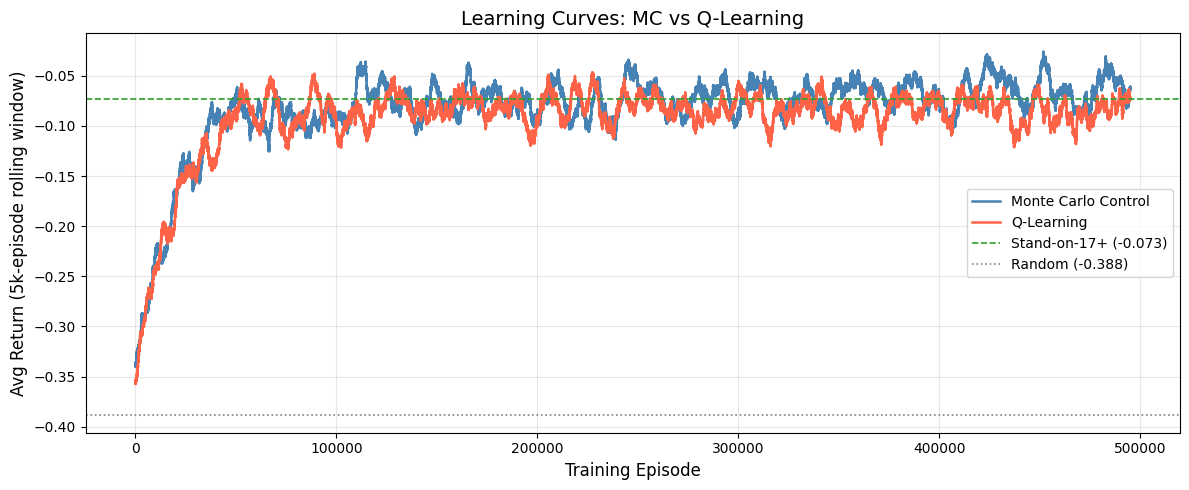

In [11]:
# --- Learning Curves ---
def smooth(data, window=5_000):
    return np.convolve(data, np.ones(window) / window, mode='valid')


fig, ax = plt.subplots(figsize=(12, 5))

for returns, label, color in [
    (mc_returns, 'Monte Carlo Control', 'steelblue'),
    (ql_returns, 'Q-Learning',          'tomato'),
]:
    s = smooth(returns, window=5_000)
    ax.plot(np.arange(len(s)), s, label=label, color=color, linewidth=1.8)

# Baseline reference lines
ax.axhline(y=baseline_threshold['avg_return'], color='#2ca02c', linestyle='--',
           linewidth=1.2, label=f"Stand-on-17+ ({baseline_threshold['avg_return']:+.3f})")
ax.axhline(y=baseline_random['avg_return'], color='gray', linestyle=':',
           linewidth=1.2, label=f"Random ({baseline_random['avg_return']:+.3f})")

ax.set_xlabel('Training Episode', fontsize=12)
ax.set_ylabel('Avg Return (5k-episode rolling window)', fontsize=12)
ax.set_title('Learning Curves: MC vs Q-Learning', fontsize=14)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

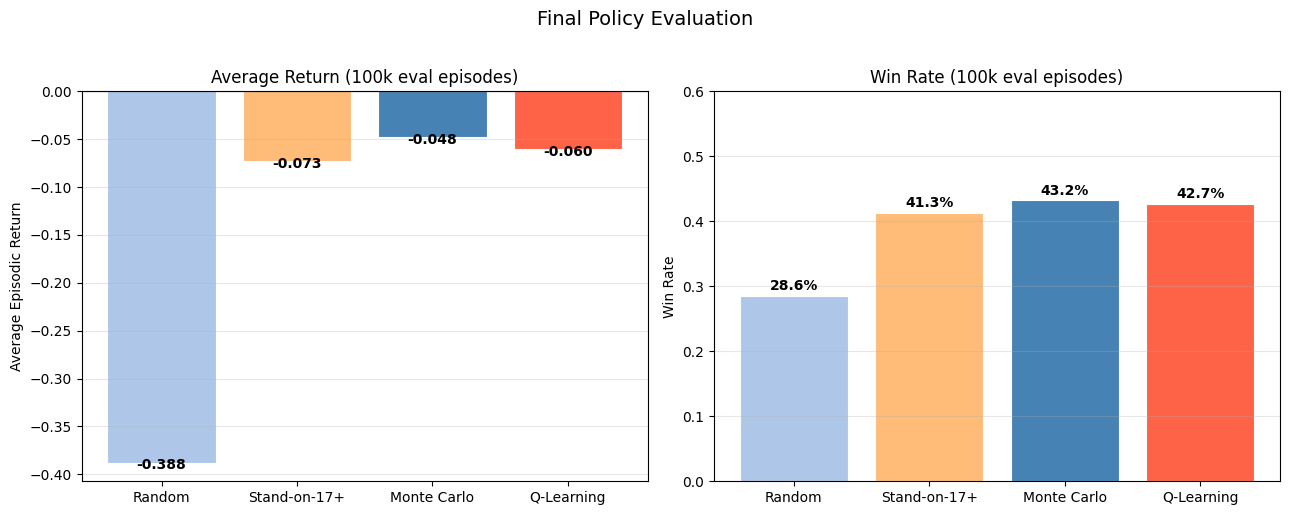

In [12]:
# --- Final Evaluation Bar Chart ---
all_labels  = ["Random", "Stand-on-17+", "Monte Carlo", "Q-Learning"]
all_results = [baseline_random, baseline_threshold, mc_results, ql_results]
colors      = ['#aec7e8', '#ffbb78', 'steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Avg Return
returns = [r['avg_return'] for r in all_results]
axes[0].bar(all_labels, returns, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(returns):
    axes[0].text(i, v + (0.004 if v >= 0 else -0.010), f"{v:+.3f}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Average Episodic Return')
axes[0].set_title('Average Return (100k eval episodes)')
axes[0].grid(axis='y', alpha=0.3)

# Win Rate
win_rates = [r['win_rate'] for r in all_results]
axes[1].bar(all_labels, win_rates, color=colors, edgecolor='white', linewidth=0.8)
for i, v in enumerate(win_rates):
    axes[1].text(i, v + 0.004, f"{v:.1%}",
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_ylabel('Win Rate')
axes[1].set_title('Win Rate (100k eval episodes)')
axes[1].set_ylim(0, 0.60)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle('Final Policy Evaluation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### GenAI disclosure:
* Used genAI to research Monte Carlo and Tabular Q-Learning
* Used genAI when got stuck with python syntax errors
* Used genAI to help with matplotlib plotting
